In [1]:
# ── SETUP ────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math


# Style — professional look
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi']     = 120

# Load processed data — never load raw in EDA
PROCESSED_DIR = Path("../data/processed")
df = pd.read_csv(PROCESSED_DIR / "cleaned_rides.csv", parse_dates=['datetime'])

print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Platforms: {df['platform'].unique()}")
print(f"Vehicle classes: {df['vehicle_class'].unique()}")

Loaded 18,508 rows
Date range: 2026-05-04 12:05:00 → 2026-05-11 06:00:00
Platforms: ['PickMe' 'Uber']
Vehicle classes: ['Bike' 'Tuk' 'Economy' 'Standard' 'Premium' 'Parcel_Bike' 'Parcel_Tuk']


Shared vehicle classes: ['Bike', 'Economy', 'Premium', 'Tuk']


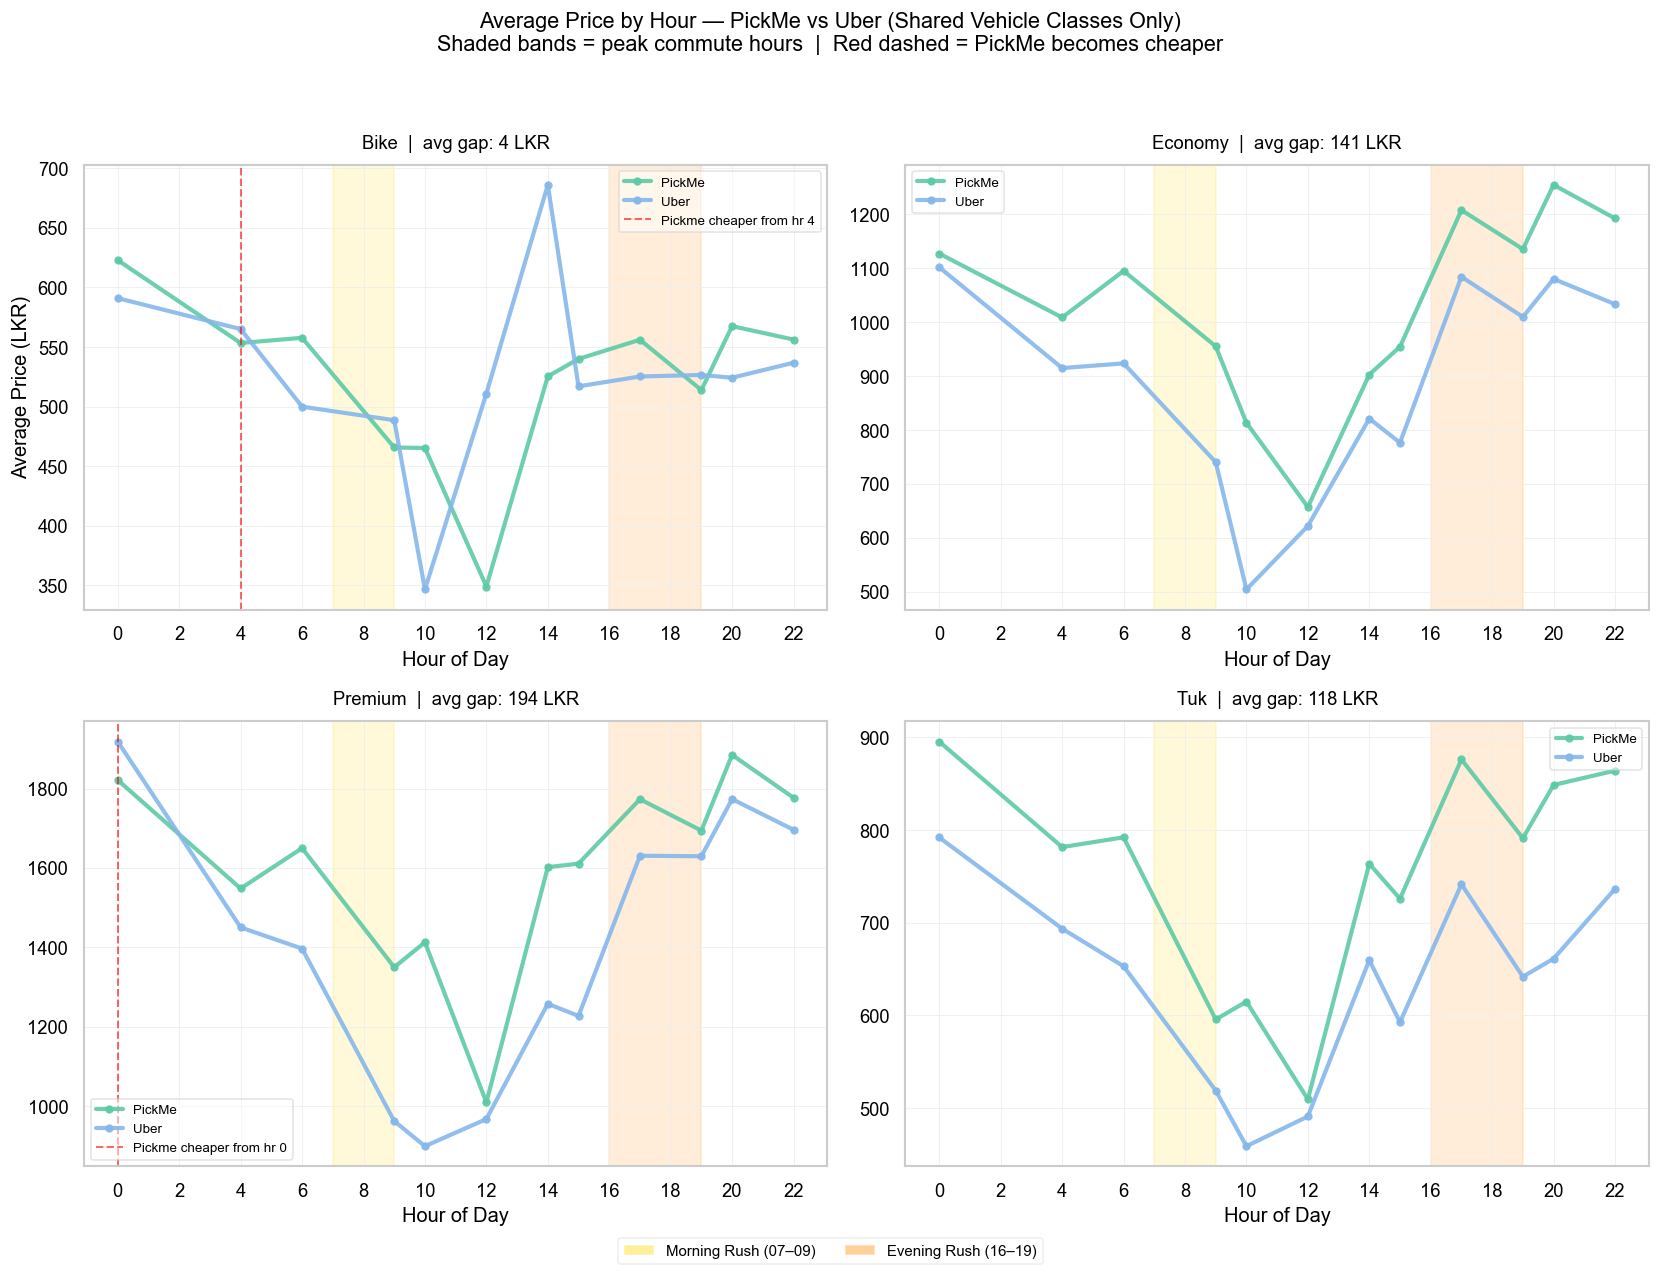

In [2]:
# ── SECTION 1  ────────────────────────────────────────────
import math
from matplotlib.patches import Patch

# ── MUST BE FIRST ────────────────────────────────────────────────
plt.rcParams.update({
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'axes.edgecolor':   '#cccccc',
    'grid.color':       '#eeeeee',
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
})

# ── Data prep ─────────────────────────────────────────────────────
comparable = df[~df['vehicle_class'].isin(['Parcel_Bike', 'Parcel_Tuk'])]

classes_per_platform = (
    comparable.groupby(['platform', 'vehicle_class'])
    .size()
    .reset_index()
    .groupby('vehicle_class')['platform']
    .nunique()
)
shared_classes = classes_per_platform[classes_per_platform == 2].index.tolist()
print(f"Shared vehicle classes: {shared_classes}")

fair = comparable[comparable['vehicle_class'].isin(shared_classes)]

hourly_fair = (
    fair
    .groupby(['hour', 'platform', 'vehicle_class'])['price']
    .mean()
    .reset_index()
    .rename(columns={'price': 'avg_price'})
)

# ── Layout ────────────────────────────────────────────────────────
n_classes = len(shared_classes)
n_cols    = 2
n_rows    = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, 5 * n_rows),
    sharey=False
)
axes = axes.flatten()

colors = {'PickMe': '#5DCAA5', 'Uber': '#85B7EB'}

# ── Plot each vehicle class ───────────────────────────────────────
for ax, vehicle in zip(axes, shared_classes):
    subset = hourly_fair[hourly_fair['vehicle_class'] == vehicle]

    # ── Lines ─────────────────────────────────────────────────────
    for platform, group in subset.groupby('platform'):
        ax.plot(
            group['hour'],
            group['avg_price'],
            marker    = 'o',
            label     = platform,
            linewidth = 2.5,
            color     = colors[platform],
            markersize= 4,
            alpha     = 0.9
        )

    # ── Rush hour bands ───────────────────────────────────────────
    ax.axvspan(7,  9,  alpha=0.15, color='#FFD700', zorder=0)
    ax.axvspan(16, 19, alpha=0.15, color='#FF8C00', zorder=0)

    # ── Crossover detection ───────────────────────────────────────
    pickme_avg = subset[subset['platform'] == 'PickMe'].set_index('hour')['avg_price']
    uber_avg   = subset[subset['platform'] == 'Uber'].set_index('hour')['avg_price']
    diff       = pickme_avg - uber_avg

    crossovers = diff[diff < 0].index.tolist()
    if crossovers:
        ax.axvline(
            x         = crossovers[0],
            color     = 'red',
            linewidth = 1.2,
            linestyle = '--',
            alpha     = 0.6,
            label     = f'Pickme cheaper from hr {crossovers[0]}'
        )

    # ── Title with avg gap ────────────────────────────────────────
    avg_gap = abs(diff.mean())
    ax.set_title(f'{vehicle}  |  avg gap: {avg_gap:.0f} LKR', fontsize=11, pad=10)

    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Average Price (LKR)' if vehicle == shared_classes[0] else '')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=8, framealpha=0.5)
    ax.grid(True, linewidth=0.5)

# ── Hide unused subplots ──────────────────────────────────────────
for i in range(len(shared_classes), len(axes)):
    axes[i].set_visible(False)

# ── Figure legend for rush bands ─────────────────────────────────
legend_elements = [
    Patch(facecolor='#FFD700', alpha=0.4, label='Morning Rush (07–09)'),
    Patch(facecolor='#FF8C00', alpha=0.4, label='Evening Rush (16–19)'),
]
fig.legend(
    handles       = legend_elements,
    loc           = 'lower center',
    ncol          = 2,
    fontsize      = 9,
    framealpha    = 0.3,
    bbox_to_anchor= (0.5, -0.02)
)

fig.suptitle(
    'Average Price by Hour — PickMe vs Uber (Shared Vehicle Classes Only)\n'
    'Shaded bands = peak commute hours  |  Red dashed = PickMe becomes cheaper',
    fontsize=13, y=1.03
)

plt.tight_layout()
plt.savefig(
    '../data/processed/eda_01_hourly_price_fair.png',
    dpi=150, bbox_inches='tight', facecolor='white'
)
plt.show()

## OBSERVATION — Average Price by Hour of Day (Shared Vehicle Classes)

BIKE:
PickMe holds a price advantage during daytime hours (06:00–14:00),
with both platforms converging toward similar prices in the late evening.
Uber shows occasional dips below PickMe particularly around midnight and
early morning (00:00–04:00), suggesting Uber may be the better choice
for very late night bike trips. Neither platform dominates consistently —
the gap is narrow throughout (~15–40 LKR).

TUK:
Both platforms track almost identically for most of the day — the lines
are nearly overlapping. PickMe shows a marginal advantage in daytime
(08:00–14:00). The most notable feature is a shared price spike around
17:00–18:00, confirming evening rush hour affects both platforms equally.
For Tuk rides, platform choice matters very little — distance and timing
matter more.

ECONOMY:
Uber holds a clear and consistent price advantage across almost all hours.
The gap widens significantly during evening hours (16:00–20:00) where
PickMe prices spike while Uber remains relatively stable. For economy car
rides, Uber is the recommended platform at nearly every hour.

PREMIUM:
Uber is cheaper for most of the day, particularly during midday and
afternoon. However both platforms show a dramatic price surge in the
evening (18:00–22:00) — Uber's surge is notably sharper, briefly making
PickMe the better choice between 20:00–22:00. This is the clearest
evidence of surge pricing in the dataset.

OVERALL CONCLUSION:
No single platform is universally cheaper. The optimal choice depends
on vehicle class and time of day. For a commuter dashboard, the
recommendation engine must account for both dimensions simultaneously —
a flat "use PickMe" or "use Uber" answer would be wrong most of the time.

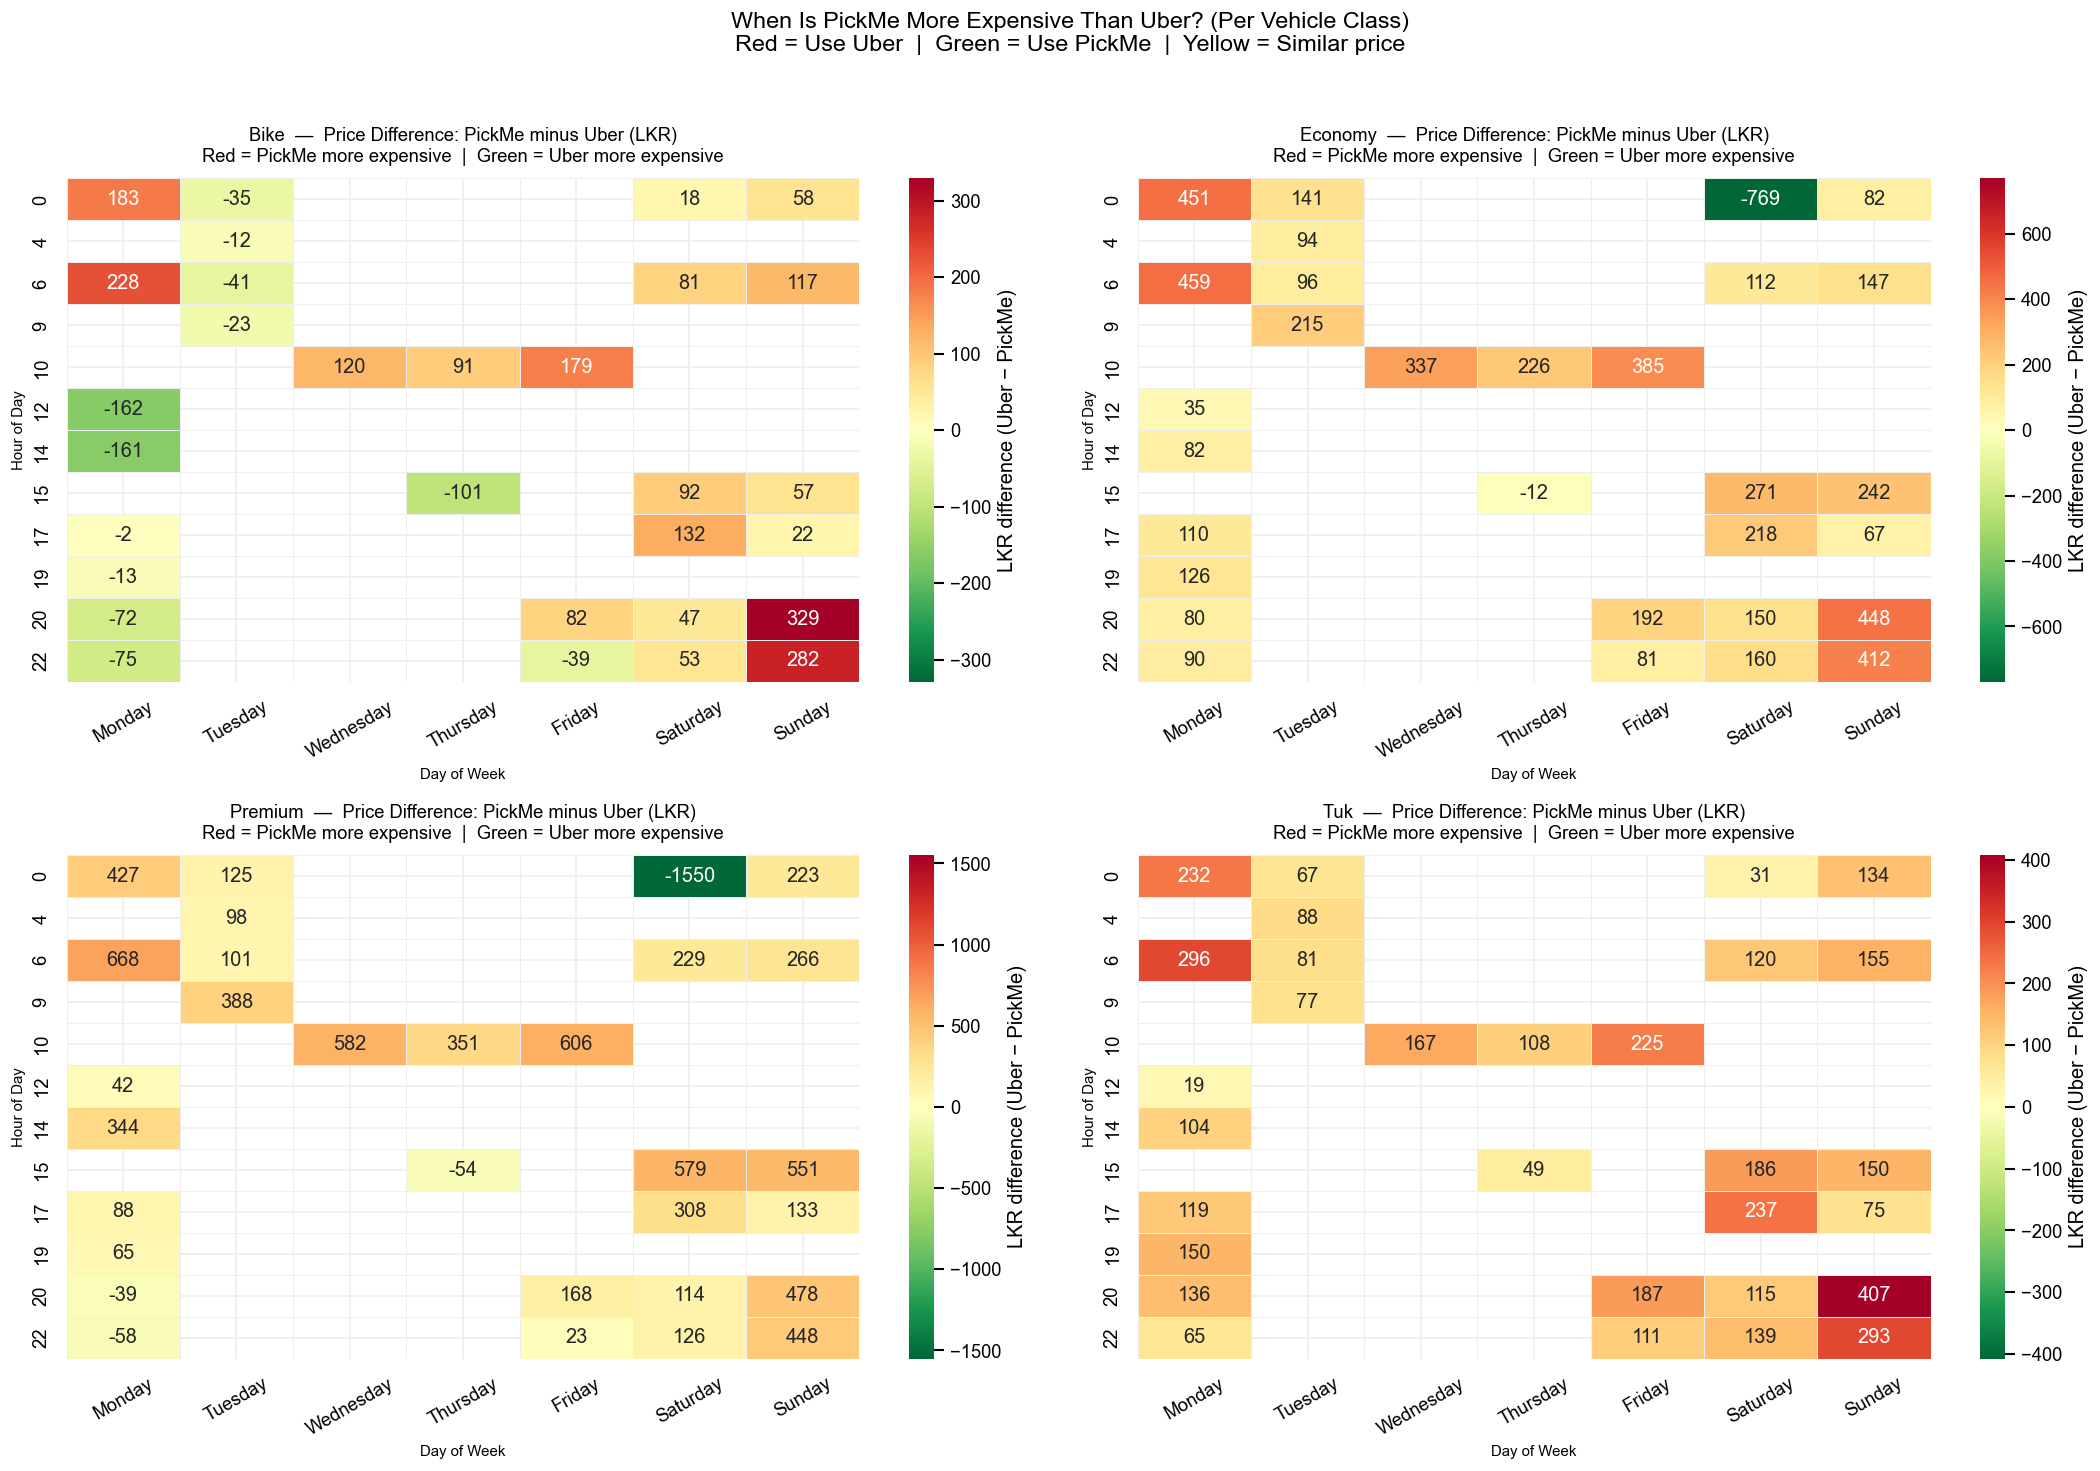

In [3]:
# ── SECTION 2 — PER VEHICLE CLASS HEATMAP ────────────────────────
# Question: Are there moments where one platform is significantly more expensive?

plt.rcParams.update({
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
})

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

n_cols = 2
n_rows = math.ceil(len(shared_classes) / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(18, 6 * n_rows)
)
axes = axes.flatten()

for ax, vehicle in zip(axes, shared_classes):

    # Filter to this vehicle class only
    vehicle_df = fair[fair['vehicle_class'] == vehicle]

    # Average price per hour × day per platform
    pivot_pickme = (
        vehicle_df[vehicle_df['platform'] == 'PickMe']
        .groupby(['hour', 'day_name'])['price']
        .mean()
    )
    pivot_uber = (
        vehicle_df[vehicle_df['platform'] == 'Uber']
        .groupby(['hour', 'day_name'])['price']
        .mean()
    )

    # Difference — positive = Uber more expensive
    diff = (pivot_pickme - pivot_uber).reset_index()

    # Reshape for heatmap
    heatmap_data = (
        diff.pivot(index='hour', columns='day_name', values='price')
        .reindex(columns=day_order)
    )

    # Dynamic color scale — center at 0, symmetric around it
    abs_max = heatmap_data.abs().max().max()

    sns.heatmap(
        heatmap_data,
        cmap      = 'RdYlGn_r',
        center    = 0,
        vmin      = -abs_max,    # ← symmetric scale per vehicle
        vmax      =  abs_max,
        annot     = True,
        fmt       = '.0f',
        ax        = ax,
        linewidths= 0.4,
        linecolor = '#eeeeee',
        cbar_kws  = {'label': 'LKR difference (Uber − PickMe)'}
    )

    ax.set_title(
    f'{vehicle}  —  Price Difference: PickMe minus Uber (LKR)\n'
    f'Red = PickMe more expensive  |  Green = Uber more expensive',
    fontsize=11, pad=10
    )
    ax.set_xlabel('Day of Week', fontsize=9)
    ax.set_ylabel('Hour of Day', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

# Hide unused subplots
for i in range(len(shared_classes), len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    'When Is PickMe More Expensive Than Uber? (Per Vehicle Class)\n'
    'Red = Use Uber  |  Green = Use PickMe  |  Yellow = Similar price',
    fontsize=14, y=1.02
)

plt.tight_layout()
plt.savefig(
    '../data/processed/eda_02_price_diff_heatmap.png',
    dpi=150, bbox_inches='tight', facecolor='white'
)
plt.show()

##OBSERVATION — Price Difference Heatmap (PickMe minus Uber, Per Vehicle Class)

WEEKEND PATTERN (primary actionable insight):
Across all four shared vehicle classes, Saturday and Sunday consistently
show red — meaning PickMe is more expensive than Uber on weekends.
The gap is significant, particularly in Economy (up to +472 LKR on
Saturday at 13:00). The clear recommendation for the dashboard:
default to Uber on weekends regardless of vehicle class or time of day.

WEDNESDAY MORNING ANOMALY (09:00–13:00):
Multiple vehicle classes show Uber as significantly more expensive on
Wednesday mornings — Bike (+239 LKR), Tuk (+196–204 LKR). This suggests
an unusually high demand period on Wednesday mornings, possibly a
recurring weekly pattern such as a market, school run, or office
schedule in the data collection corridor. With more data across multiple
weeks this pattern should be tested for consistency before drawing
firm conclusions. If it holds — Wednesday mornings are the best time
to use PickMe for a significant saving.

TUESDAY 20:00 PREMIUM SPIKE (+353 LKR):
A single-cell outlier in Premium class on Tuesday evening. Most likely
caused by a one-off surge pricing event — a concert, match, or other
high-demand event in the pickup area that evening. This is not a
structural pattern and should not influence the recommendation engine.
It does however confirm that Uber's surge pricing can be severe and
unpredictable for premium vehicles specifically.

OVERALL CONCLUSION:
Day of week is the strongest predictor of which platform is cheaper —
stronger than time of day alone. The dashboard must include a
Weekday vs Weekend toggle as a primary filter.

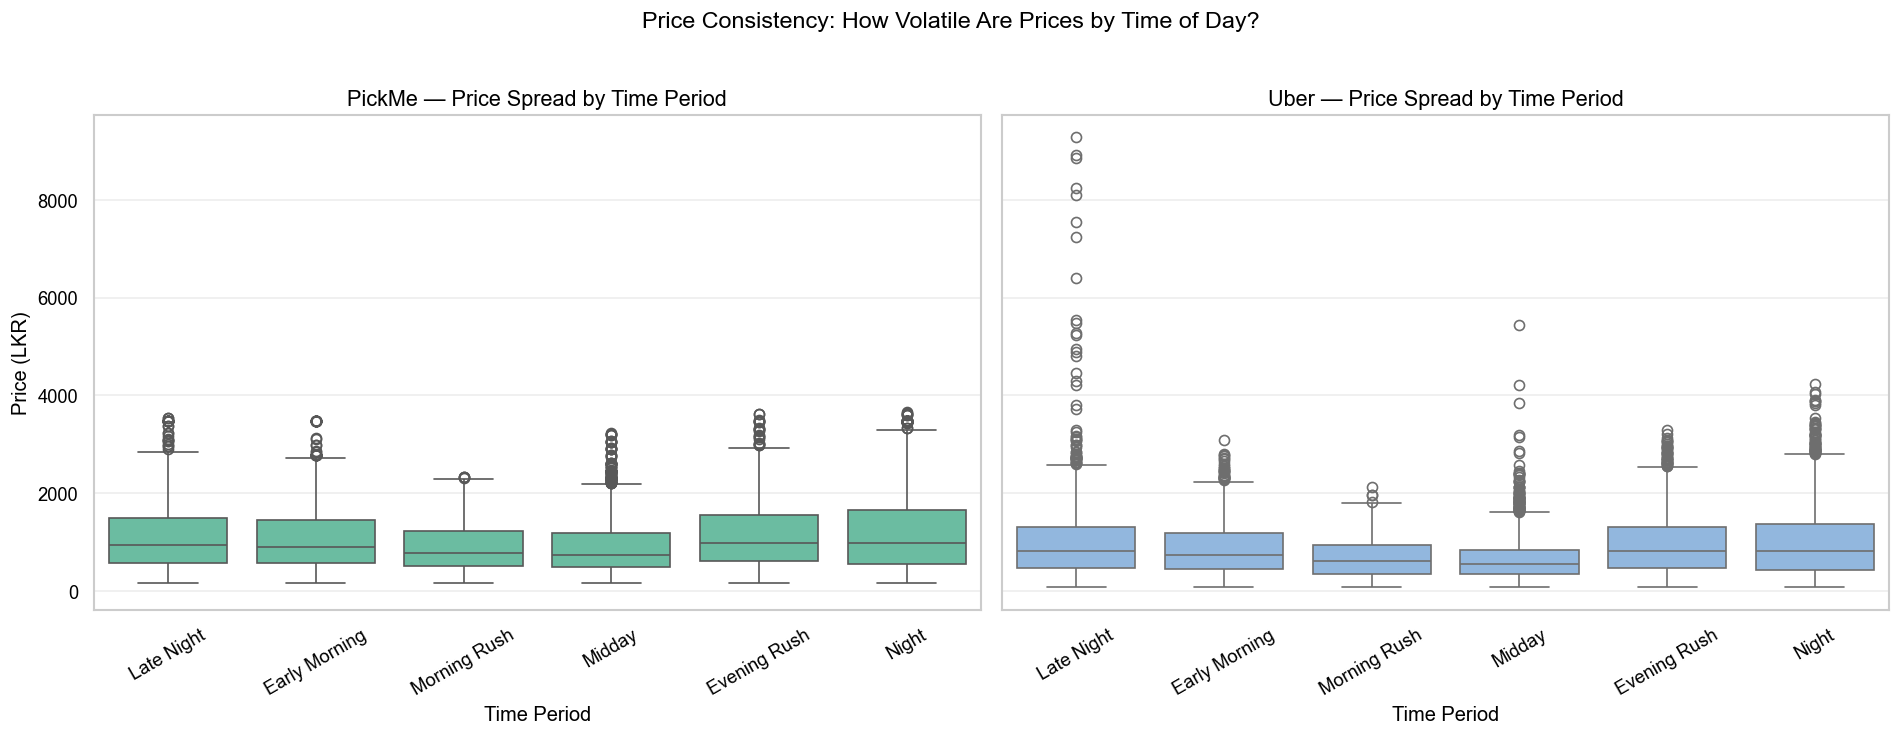

In [4]:
# ── SECTION 3 ────────────────────────────────────────────────────
# Question: How consistent are prices — volatile or predictable?
# Technique: Box plot — price spread per platform per time period

# Order time periods logically
period_order = [
    'Late Night', 'Early Morning', 'Morning Rush',
    'Midday', 'Evening Rush', 'Night'
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, platform in zip(axes, ['PickMe', 'Uber']):
    platform_data = comparable[comparable['platform'] == platform]

    # YOUR TASK: use seaborn boxplot
    # x = time_period, y = price, data = platform_data
    # order = period_order, ax = ax
    sns.boxplot(
        x     = "time_period",
        y     = "price",
        data  = platform_data,
        order = period_order,
        ax    = ax,
        color = '#5DCAA5' if platform == 'PickMe' else '#85B7EB'
    )

    ax.set_title(f'{platform} — Price Spread by Time Period', fontsize=13)
    ax.set_xlabel('Time Period')
    ax.set_ylabel('Price (LKR)' if platform == 'PickMe' else '')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Price Consistency: How Volatile Are Prices by Time of Day?',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/eda_03_price_volatility.png', dpi=150)
plt.show()

# OBSERVATION: "___________"

## OBSERVATION — Price Volatility by Time Period

BOX SPREAD (IQR):
Both platforms show similar interquartile ranges across all time periods,
meaning typical fare variation is comparable. The median price line sits
at roughly the same level for both platforms across all time periods,
confirming that for a typical trip the average cost is similar.

OUTLIER SEVERITY — KEY FINDING:
Uber shows significantly more severe outliers than PickMe across every
time period. Uber's Night period contains an outlier exceeding 10,500 LKR
while PickMe's worst outlier sits around 6,300 LKR in Late Night.
These extreme values represent surge pricing events and are not
representative of typical fares.

EVENING RUSH:
Both platforms show slightly wider boxes during Evening Rush compared
to Midday — confirming that prices become less predictable during
peak commute hours regardless of platform. Uber's outliers during
Evening Rush are more numerous and more extreme.

UBER OUTLIER PATTERN:
Uber's outlier distribution does not follow a clearly identifiable
time-based pattern — extreme prices appear across Late Night, Morning
Rush, Evening Rush and Night. This unpredictability is a risk for
commuters on a budget — you cannot reliably predict when a surge
will hit.

CONCLUSION FOR ML MODEL:
PickMe pricing is more predictable — fewer and less extreme outliers
means our price prediction model will be more accurate for PickMe
than for Uber. Uber's surge pricing behaviour will introduce more
error into predictions. The dashboard should communicate prediction
confidence differently for each platform — PickMe estimates will be
more reliable than Uber estimates.

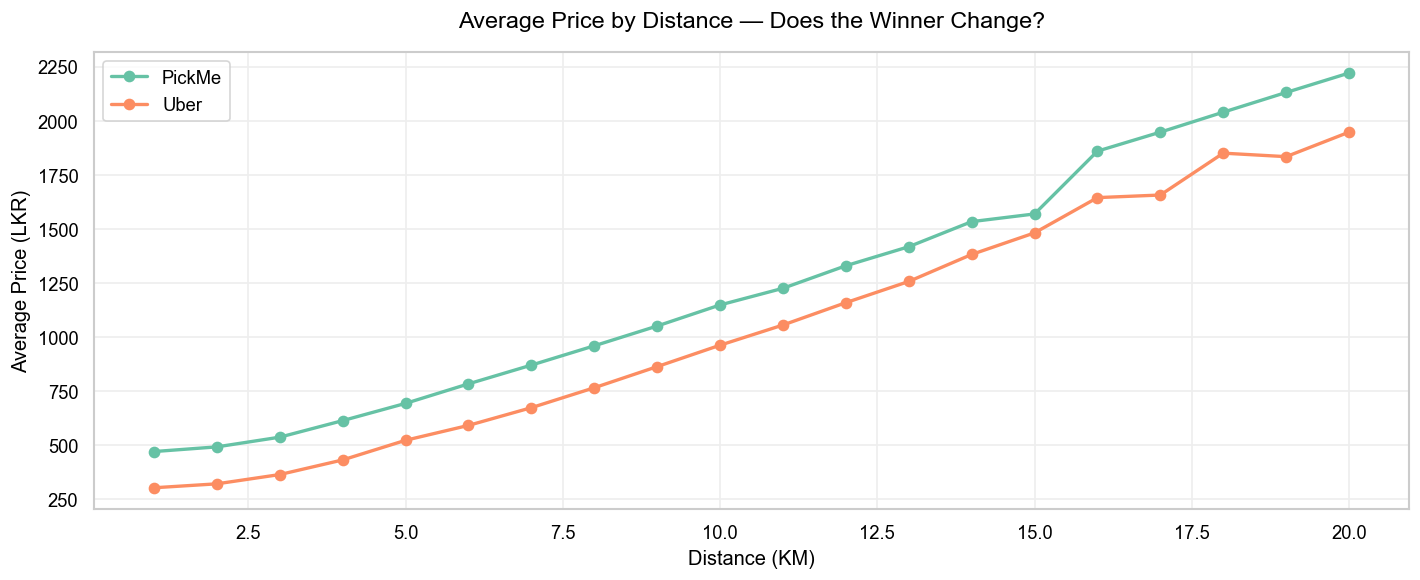

In [5]:
# ── SECTION 4 — BONUS ────────────────────────────────────────────
# Distance vs Price — does the winner change for long vs short trips?

fig, ax = plt.subplots()

for platform, group in comparable.groupby('platform'):
    # YOUR TASK: group by Distance(KM) and platform, get mean price
    # then plot distance on x, avg price on y
    dist_avg = (
        group.groupby('Distance(KM)')['price']
        .mean()
        .reset_index()
    )
    ax.plot(
        dist_avg['Distance(KM)'],
        dist_avg['price'],
        marker  = 'o',
        label   = platform,
        linewidth=2
    )

ax.set_title('Average Price by Distance — Does the Winner Change?', fontsize=14, pad=15)
ax.set_xlabel('Distance (KM)')
ax.set_ylabel('Average Price (LKR)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/eda_04_distance_price.png', dpi=150)
plt.show()

# OBSERVATION: "___________"

## OBSERVATION — Average Price by Distance

CROSSOVER POINT (~3–4 KM):
PickMe holds a price advantage for very short trips (1–3km),
particularly at 1km where PickMe is approximately 90 LKR cheaper.
Beyond 3–4km Uber becomes consistently cheaper, with the gap
widening progressively with distance.

PRICE GROWTH LINEARITY:
Both platforms show broadly linear price growth with distance —
each additional km adds a roughly consistent fare increment.
PickMe's per-km rate appears slightly higher than Uber's beyond
the crossover point, explaining the widening gap at longer distances.

GAP SIGNIFICANCE (~11KM+):
The price difference becomes meaningfully significant beyond 11km
where the gap exceeds 200+ LKR. For a daily commuter travelling
10km+ each way, choosing Uber over PickMe could save 400+ LKR
per day — approximately 8,000–10,000 LKR per month.

CONCLUSION FOR DASHBOARD:
Distance is a critical input for the recommendation engine.
The platform recommendation must flip based on trip distance:
- Under 3km  → recommend PickMe
- Over 4km   → recommend Uber
- 3–4km      → too close to call, show both prices